---
authors: RTahlia van den Berg, Eline Deiters
updated: December 3, 2025
---
# Ballon proef
<!-- vervang bovenstaande titel -->

# Introductie

Volgens [de ideale gaswet](https://nl.wikipedia.org/wiki/Algemene_gaswet) wordt het volume $V$ van een (ideaal) gas gegeven door: 

$$
    V = n R T / P
$$

waarin 

- $n$ het aantal mol gas,
- $R$ de ideale gasconstante,
- $T$ de absolute temperatuur,
- $P$ de druk.

In dit practicum veranderen we de temperatuur en meten we de verandering van het volume van het gas. De proef is met name kwalitatief van aard en laat zien hoe lastig het is een extensieve grootheid als volume te meten.  

# Methode en materialen

## Ontwerp

Om het volume van een hoeveelheid gas bij constante druk te meten is niet zo eenvoudig. Je kunt het gas vrij eenvoudig in een ballon stoppen en dan schatten hoe de diameter van de ballon verandert als functie van de temperatuur, maar dat geeft een relatief grote fout (waarom?). We maken daarom gebruik van de wet van [Archimedes](https://nl.wikipedia.org/wiki/Wet_van_Archimedes). 

## Materialen

- eenvoudige feestballon
- bekerglas
- tweede bekerglas om mee bij te vullen
- thermometer
- verhittingsplaat
- deksel met vulcilinder met maatstrepen (met iets kleinere diameter dan interne diameter maatbeker)
- (per 5 groepjes) een $10 \mathrm{ml}$ maatcilinder

## Procedure

- Blaas de ballon op, maar niet verder dan $5 \mathrm{cm}$ in diameter. Deze moet makkelijk in de maatbeker passen. 
- Knoop de ballon goed dicht zodat er geen lucht kan ontsnappen. 
- Dompel de ballon onder in de maatbeker met water met behulp van het deksel.
- Pas het waterniveau aan zodat de meniscus (de bovenkant van het water) bij een van de onderste maatstrepen van de vulcilinder van het deksel zit. 
- Let op dat er luchtbellen kunnen plakken aan de ballon wat leidt tot een systematische fout. Verifieer dat je zo min mogelijk systematische fouten maakt en meet op welke maatstreep de meniscus zich bevindt.
- Verhoog stapsgewijst de temperatuur van het water (en dus de ballon). *Let op dat je de temperatuur maximaal een graad of 20 kan verhogen, want als je voorbij de vulcilinder komt met de meniscus, dan kan je de volumeverandering niet meer nauwkeurig bepalen.*
- Laat het geheel na elke temperatuurtoename een minuut 'rusten' om zo de tijd te geven om in thermisch evenwicht te komen.
- Meet na elke temperatuurtoename de temperatuur en de positie van de meniscus.

Het verschiloppervlak tussen de binnendiameter van de maatbeker en de buitendiameter van de vulcilinder is $10.0 \mathrm{cm}^{2}$. Je kunt die handmatig kalibreren met behulp van de kleine maatcilinder die in het lokaal aanwezig is. De maatstreepjes die op de vulcilinder zijn gekerfd zitten op een onderlinge afstand van $1.0 \mathrm{mm}$.

```{exercise} Analyseer de data
Plot de volumeverandering van de ballon als functie van de temperatuur. Zie je hier een lineair verband? Bepaal dan ook wat het startvolume van de ballon was door te extrapoleren naar een absolute temperatuur van $0 \mathrm{K}$.


```{solution} 
er is wel een lineare verband, hoewel onze metingen niet al te netjes op the curve fit liggen. De start volume van de ballon is ongeveer 206 ccm. 

Als je kritisch nadenkt over deze grafiek en de extrapolatie, dan kun je bezwaar maken tegen de precisie van deze proef. Het water in de maatbeker zet ook uit onder de verhoging van de temperatuur en geeft een systematische fout. Daar kun je een correctie voor uitvoeren. Voer die correctie uit als je nog genoeg tijd hebt:

```{exercise} Verbeterde meting
- Maak de maatbeker leeg en vul deze opnieuw met water tot een van de onderste maatstrepen van de vulcilinder (dus zonder ballon). 
- Verhit de maatbeker weer stapsgewijs en meet na elke stap de temperatuur en de hoogte van de meniscus.

Kun je nu met behulp van deze tweede meting een betere afschatting geven voor het startvolume van de ballon? 

```{solution}
Nee, omdat onze volume niet veel meer toegenomen is. Alleen tot ongeveer halverwegen onze metingen is de water een paar streepjes omhoog gegaan, maar wij vermoeden dat dat met namelijks door de bubbels in de water komt. 

# Resultaten

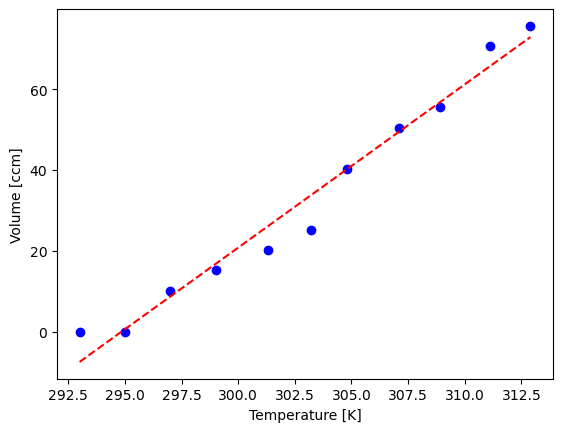

[ 0.          0.         10.08663299 15.12994949 20.17326599 25.21658248
 40.34653197 50.43316497 55.47648146 70.60643095 75.64974745] [293.  295.  297.  299.  301.3 303.2 304.8 307.1 308.9 311.1 312.9]


In [6]:

import numpy as np
import matplotlib.pyplot as plt

temps = [20.0, 22.0, 24.0, 26.0, 28.3, 30.2, 31.8, 34.1, 35.9, 38.1, 39.9]
hoogtes = [3.0, 3.0, 4.0, 4.5, 5.0, 5.5, 7.0, 8.0, 8.5, 10.0, 10.5]


diam_beker = 7.66 # cm
diam_deksel = 6.77 # cm
opp_water = 1/4 * np.pi * (diam_beker**2 - diam_deksel**2) #cm2

volumes = (np.asarray(hoogtes) - hoogtes[0]) * opp_water
temps_abs = np.asarray(temps) + 273
coef = np.polyfit(temps_abs, volumes, 1)
func = np.poly1d(coef)

plt.plot(temps_abs, volumes, 'ob')
plt.plot(temps_abs, func(temps_abs), '--r')
plt.xlabel('Temperature [K]')
plt.ylabel('Volume [ccm]')
plt.show()

print(volumes, temps_abs)

In [15]:
## extrapoleren:

helling = (max(volumes) - volumes[5]) / (max(temps_abs) - temps_abs[5])

vol_totaal = helling*(min(temps_abs) - temps_abs[5]) + temps_abs[5]

hoogte_deksel = 1.2 #cm

vol_deksel = np.pi * (diam_deksel / 2)**2 * hoogte_deksel

vol_ballon = vol_totaal - vol_deksel

print('De originele volume van de ballon is ', np.round(vol_ballon, 3) , 'ccm')

De originele volume van de ballon is  206.971 ccm


# Discussie en conclusie




De volume van de ballon is groter geworden, omdat de temperatuur verhoogd is. De moleculen botsen hierdoor harder tegen de wanden. Waardoor de druk ook toeneemt. Wegens de vergroting van de ballon, is het water in de maatcilinder omhoog gegaan. In onze grafiek zie je punten die afwijken van de curve fit. Dit komt omdat we soms moeite hadden met het aflezen van de streepjes op de deksel. Dit kan ook komen door de bubbels van lucht in het water, die zorgde voor afwijkingen in het volume van het water. 

Het verschil van het water konden  we gebruiken om de eind en begin volume van de ballon te berekenen door middel van extrapoleren. Hiermee zijn we op een begin volume (van de ballon) gekomen van 207 ccm en ons eind volume (van de ballon) van 283 ccm. We hadden ook verwacht dat de volume zou toenemen naarmate de temperatuur stijgt. Hierna hebben we een experiment uitgevoerd om de uitzetting van water te berekenen. Hier zagen we geen verschil in, dus hier hebben we geen rekening mee gehouden in de berekeningen. 